# 04 — ¿La mejora semanal también mejora el pronóstico diario?

Se reemplaza únicamente el total semanal de 14 por `Memoria_larga` de 15. Se conservan los pesos uniforme, perfil de ocho semanas y boosting de 02, y su pronóstico autónomo. Así se distingue el efecto del total del efecto del reparto; no se reentrena ni se selecciona una nueva forma mirando 2026.

Entradas: predicciones diarias de 02 y predicciones semanales de 15. Salidas: Parquet y Excel propios, sin sobrescribir el experimento original. Alcance: H1, siete días emitidos al lunes, producción/clima conocidos al origen. No es actualización intrasemanal ni prueba de H2–H5 diarios. El candidato semanal fue elegido retrospectivamente: esta evaluación también es retrospectiva.

Se evalúan los mismos días observados para todos los métodos. Los días sin reporte permanecen faltantes. Se añade una sensibilidad en semanas con siete días observados y otra sobre la comparación semanal estricta.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').exists())
DIARIO=ROOT/'Datos_analiticos_proyecto/modelo_diario'
SEMANAL=ROOT/'Datos_analiticos_proyecto/modelo_con_proyecciones_teoricas'
FIG=ROOT/'Trabajo escrito/Figuras_resultados'; FIG.mkdir(exist_ok=True)
KEY=['finca','producto','color','variedad']; WK=KEY+['origen']
pred=pd.read_parquet(DIARIO/'predicciones_diarias_2026.parquet')
semanal=pd.read_parquet(SEMANAL/'experimentos_horizontes_2026.parquet')
semanal=semanal.loc[semanal.horizonte.eq(1)]
assert not semanal.duplicated(WK).any()
pred=pred.merge(semanal[WK+['Memoria_larga','Sistema_diario','grupo_comparacion','corte_entrenamiento_nuevo']],on=WK,how='left',validate='many_to_one',suffixes=('','_verificacion'))
assert pred.Memoria_larga.notna().all()
assert np.allclose(pred.Sistema_diario,pred.Sistema_diario_verificacion)
assert pred.corte_entrenamiento_nuevo.le(pred.origen).all()
assert pred.groupby(WK).size().eq(7).all()
pred['Uniforme_memoria']=pred.Memoria_larga/7
pred['Perfil_memoria']=pred.Memoria_larga*pred.peso_perfil
pred['Boosting_memoria']=pred.Memoria_larga*pred.peso_boost
metodos=['Uniforme_semanal','Perfil_8semanas','Boosting_reconciliado','Boosting_diario','Uniforme_memoria','Perfil_memoria','Boosting_memoria']
assert np.isfinite(pred[metodos]).all().all() and pred[metodos].ge(0).all().all()
for metodo in ['Uniforme_memoria','Perfil_memoria','Boosting_memoria']:
    assert np.allclose(pred.groupby(WK)[metodo].sum(),pred.groupby(WK).Memoria_larga.first(),rtol=1e-10,atol=1e-6)
pred['semana_completa']=pred.groupby(WK).tallos.transform('count').eq(7)
print('Semanas:',pred.groupby(WK).ngroups,'días:',len(pred),'observados:',pred.tallos.notna().sum(),'semanas de siete reportes:',pred.loc[pred.semana_completa].groupby(WK).ngroups)
print('Verificado: mismos totales anteriores, claves únicas, cortes temporales y suma diaria = nuevo total semanal.')

Semanas: 4139 días: 28973 observados: 22973 semanas de siete reportes: 274
Verificado: mismos totales anteriores, claves únicas, cortes temporales y suma diaria = nuevo total semanal.


## 1. Precisión: total semanal anterior frente al nuevo

WAPE = suma de errores absolutos / suma de producción observada. MAE y RMSE se expresan en tallos por día y serie. Sesgo positivo significa subestimación. El modelo autónomo no está obligado a sumar al total semanal; los seis repartos sí lo están. Una mejora semanal no garantiza mejorar cada día.

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Boosting_diario,22973.0,542.839640,974.865466,0.267189,144.382353
Boosting_memoria,22973.0,557.452844,999.644945,0.274382,126.081714
Perfil_memoria,22973.0,565.879768,1008.770714,0.278530,117.497280
Boosting_reconciliado,22973.0,574.774694,1043.179280,0.282908,151.608698
Perfil_8semanas,22973.0,582.076714,1049.850854,0.286502,143.158820
Uniforme_memoria,22973.0,589.478864,1095.352043,0.290145,346.046078
Uniforme_semanal,22973.0,608.101643,1145.799282,0.299312,367.891837


,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Boosting_diario,1918.0,605.520074,995.386108,0.247303,188.893620
Boosting_memoria,1918.0,826.912737,1403.253366,0.337722,197.393057
Boosting_reconciliado,1918.0,835.403003,1414.974492,0.341190,172.989611
Perfil_8semanas,1918.0,875.139344,1474.809638,0.357419,172.989611
Perfil_memoria,1918.0,868.653140,1462.484172,0.354770,197.393057
Uniforme_memoria,1918.0,600.340186,944.208074,0.245187,197.393057
Uniforme_semanal,1918.0,600.565261,949.400928,0.245279,172.989611


,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Boosting_diario,19411.0,593.247549,1039.272368,0.267094,156.755732
Boosting_memoria,19411.0,601.414283,1052.072363,0.270771,148.137630
Boosting_reconciliado,19411.0,622.006133,1101.804802,0.280042,177.044822
Perfil_8semanas,19411.0,629.103753,1107.862192,0.283237,167.979195
Perfil_memoria,19411.0,610.029884,1060.640902,0.274650,138.912538
Uniforme_memoria,19411.0,646.791166,1172.503283,0.291200,393.062288
Uniforme_semanal,19411.0,668.488741,1227.899954,0.300969,417.539079


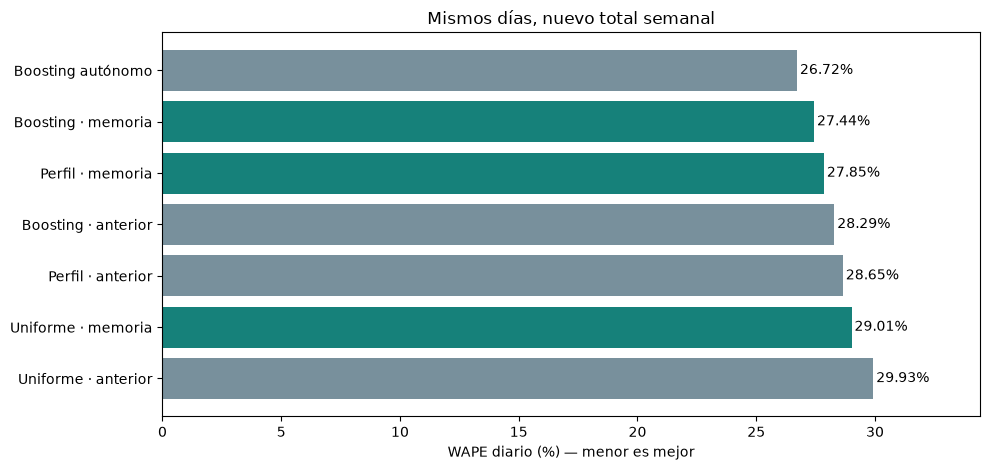

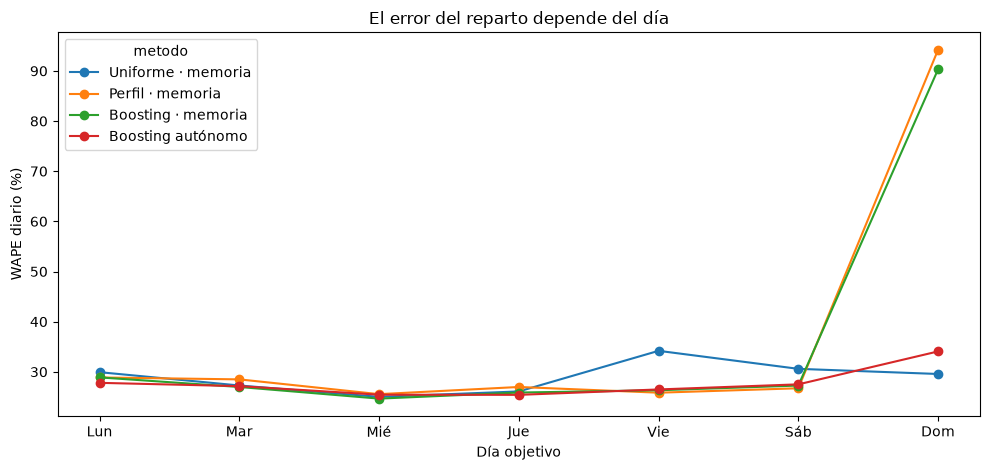

n          MAE         RMSE  \
dia_objetivo metodo                                                    
0            Boosting_diario        3389.0   566.526063   965.719708   
             Boosting_memoria       3389.0   588.692320   998.047000   
             Boosting_reconciliado  3389.0   602.823987  1025.816735   
             Perfil_8semanas        3389.0   605.484133  1030.239170   
             Perfil_memoria         3389.0   588.398842   996.076060   
             Uniforme_memoria       3389.0   609.865154  1049.390745   
             Uniforme_semanal       3389.0   621.365650  1072.624110   
1            Boosting_diario        3921.0   504.282974   871.506940   
             Boosting_memoria       3921.0   501.160657   856.907109   
             Boosting_reconciliado  3921.0   505.341800   869.616230   
             Perfil_8semanas        3921.0   535.473253   923.212457   
             Perfil_memoria         3921.0   529.356745   902.639930   
             Uniforme_memoria       3921.0   506.714839   891.228936   
             Uniforme_semanal       3921.0   517.489169   921.718925   
2            Boosting_diario        3900.0   471.897513   840.690406   
             Boosting_memoria       3900.0   457.455527   787.062081   
             Boosting_reconciliado  3900.0   467.872123   811.770709   
             Perfil_8semanas        3900.0   485.810900   862.862179   
             Perfil_memoria         3900.0   473.936018   833.409975   
             Uniforme_memoria       3900.0   463.966315   826.303101   
             Uniforme_semanal       3900.0   477.307107   868.181903   
3            Boosting_diario        3897.0   496.161517   906.923932   
             Boosting_memoria       3897.0   505.103701   912.751180   
             Boosting_reconciliado  3897.0   520.898899   961.927037   
             Perfil_8semanas        3897.0   543.999098   989.398880   
             Perfil_memoria         3897.0   526.814079   941.528721   
             Uniforme_memoria       3897.0   509.450119   950.316622   
             Uniforme_semanal       3897.0   533.597513  1007.241988   
4            Boosting_diario        3676.0   614.268692  1085.224615   
             Boosting_memoria       3676.0   610.510432  1073.933630   
             Boosting_reconciliado  3676.0   650.042604  1165.667736   
             Perfil_8semanas        3676.0   632.749594  1121.200234   
             Perfil_memoria         3676.0   599.241348  1038.949195   
             Uniforme_memoria       3676.0   792.913217  1439.606791   
             Uniforme_semanal       3676.0   821.692211  1518.332967   
5            Boosting_diario        3901.0   600.489569  1127.551510   
             Boosting_memoria       3901.0   595.273750  1096.612695   
             Boosting_reconciliado  3901.0   617.369563  1152.844239   
             Perfil_8semanas        3901.0   597.114472  1108.971741   
             Perfil_memoria         3901.0   583.426687  1068.356022   
             Uniforme_memoria       3901.0   668.100561  1305.576299   
             Uniforme_semanal       3901.0   692.489170  1366.831364   
6            Boosting_diario         289.0   688.240198  1238.609644   
             Boosting_memoria        289.0  1824.809839  2700.991450   
             Boosting_reconciliado   289.0  1824.649826  2703.908635   
             Perfil_8semanas         289.0  1904.892517  2786.806430   
             Perfil_memoria          289.0  1903.670598  2781.997906   
             Uniforme_memoria        289.0   597.339190   960.271646   
             Uniforme_semanal        289.0   595.736278   974.360097   

                                        WAPE        sesgo  
dia_objetivo metodo                                        
0            Boosting_diario        0.277968   220.482626  
             Boosting_memoria       0.288844   311.913205  
             Boosting_reconciliado  0.295778   325.801416  
             Perfil_8semanas        0.297083   201.837542  
        

n         MAE        RMSE      WAPE  \
producto       metodo                                                           
ACHILLEA       Boosting_diario         49.0   12.535767   18.438961  0.400165   
               Boosting_memoria        49.0   32.631158   40.220415  1.041646   
               Boosting_reconciliado   49.0   48.591329   68.650566  1.551124   
               Perfil_8semanas         49.0   63.896257   95.719988  2.039685   
               Perfil_memoria          49.0   42.065064   55.196826  1.342794   
...                                     ...         ...         ...       ...   
VERONICA SPRAY Boosting_reconciliado  595.0  148.219484  198.460559  0.346336   
               Perfil_8semanas        595.0  147.283297  197.739483  0.344148   
               Perfil_memoria         595.0  146.045597  194.365016  0.341256   
               Uniforme_memoria       595.0  143.446041  197.407297  0.335182   
               Uniforme_semanal       595.0  144.780808  199.677113  0.338301   

                                          sesgo  
producto       metodo                            
ACHILLEA       Boosting_diario        10.810043  
               Boosting_memoria        1.142851  
               Boosting_reconciliado -18.150215  
               Perfil_8semanas       -32.005690  
               Perfil_memoria         -6.812570  
...                                         ...  
VERONICA SPRAY Boosting_reconciliado  18.716007  
               Perfil_8semanas        16.860617  
               Perfil_memoria         19.947027  
               Uniforme_memoria       76.198411  
               Uniforme_semanal       73.457964  

[91 rows x 5 columns]

n         MAE         RMSE      WAPE  \
origen  metodo                                                             
2026-01 Boosting_diario        2861.0  485.980397   830.524418  0.289498   
        Boosting_memoria       2861.0  573.017174  1008.253892  0.341345   
        Boosting_reconciliado  2861.0  569.936712   997.021850  0.339510   
        Perfil_8semanas        2861.0  587.543747  1015.203326  0.349999   
        Perfil_memoria         2861.0  591.486911  1024.719995  0.352348   
        Uniforme_memoria       2861.0  488.960353   810.850003  0.291273   
        Uniforme_semanal       2861.0  490.458196   813.210421  0.292165   
2026-02 Boosting_diario        2676.0  598.583900  1077.843610  0.302464   
        Boosting_memoria       2676.0  597.598084  1081.349108  0.301966   
        Boosting_reconciliado  2676.0  617.175039  1138.534004  0.311858   
        Perfil_8semanas        2676.0  619.208194  1149.369060  0.312886   
        Perfil_memoria         2676.0  598.535764  1091.280113  0.302440   
        Uniforme_memoria       2676.0  649.068384  1203.419480  0.327974   
        Uniforme_semanal       2676.0  667.349815  1264.807113  0.337212   
2026-03 Boosting_diario        3218.0  628.599674  1153.050310  0.269235   
        Boosting_memoria       3218.0  602.996302  1090.747899  0.258269   
        Boosting_reconciliado  3218.0  619.036242  1106.352922  0.265139   
        Perfil_8semanas        3218.0  630.302223  1129.722795  0.269964   
        Perfil_memoria         3218.0  610.812401  1111.691785  0.261616   
        Uniforme_memoria       3218.0  682.558435  1291.850955  0.292346   
        Uniforme_semanal       3218.0  669.479677  1268.954260  0.286744   
2026-04 Boosting_diario        2739.0  528.624998   915.181569  0.236414   
        Boosting_memoria       2739.0  644.427122  1154.353717  0.288204   
        Boosting_reconciliado  2739.0  651.074517  1171.119591  0.291177   
        Perfil_8semanas        2739.0  669.704149  1205.444660  0.299508   
        Perfil_memoria         2739.0  663.487527  1189.532672  0.296728   
        Uniforme_memoria       2739.0  501.342330   873.029559  0.224213   
        Uniforme_semanal       2739.0  504.703164   894.511949  0.225716   
2026-05 Boosting_diario        2681.0  491.715161   823.100037  0.240915   
        Boosting_memoria       2681.0  493.019295   853.986131  0.241554   
        Boosting_reconciliado  2681.0  520.313726   912.391447  0.254927   
        Perfil_8semanas        2681.0  509.388655   891.464837  0.249574   
        Perfil_memoria         2681.0  485.542530   835.087187  0.237891   
        Uniforme_memoria       2681.0  575.256467   997.279622  0.281846   
        Uniforme_semanal       2681.0  605.854987  1058.111200  0.296838   
2026-06 Boosting_diario        3134.0  540.106685   934.052210  0.273614   
        Boosting_memoria       3134.0  523.921785   920.436362  0.265415   
        Boosting_reconciliado  3134.0  548.552018  1003.128460  0.277892   
        Perfil_8semanas        3134.0  565.122720  1025.625816  0.286287   
        Perfil_memoria         3134.0  547.219089   952.548021  0.277217   
        Uniforme_memoria       3134.0  589.814876  1097.914768  0.298796   
        Uniforme_semanal       3134.0  635.119426  1206.650246  0.321746   
2026-07 Boosting_diario        2472.0  530.356031   979.157599  0.264722   
        Boosting_memoria       2472.0  480.945601   849.654674  0.240059   
        Boosting_reconciliado  2472.0  519.213784   957.042561  0.259160   
        Perfil_8semanas        2472.0  517.996046   930.055287  0.258552   
        Perfil_memoria         2472.0  481.266062   828.806849  0.240219   
        Uniforme_memoria       2472.0  608.492642  1148.145769  0.303723   
        Uniforme_semanal       2472.0  653.137493  1258.412458  0.326007   
2026-08 Boosting_diario        3192.0  528.099682  1010.172732  0.266462   
        Boosting_memoria       3192.0  535.591620   976.843321  0.270243   
        

In [2]:
observados=pred.loc[pred.tallos.notna()].copy()
larga=observados.melt(id_vars=WK+['fecha','dia_objetivo','semana_completa','grupo_comparacion','tallos'],value_vars=metodos,var_name='metodo',value_name='prediccion')
def evaluar(g):
    e=g.tallos-g.prediccion
    return pd.Series({'n':len(g),'MAE':e.abs().mean(),'RMSE':np.sqrt((e**2).mean()),'WAPE':e.abs().sum()/g.tallos.sum(),'sesgo':e.mean()})
resumen=larga.groupby('metodo').apply(evaluar)
por_dia=larga.groupby(['dia_objetivo','metodo']).apply(evaluar)
por_producto=larga.groupby(['producto','metodo']).apply(evaluar)
por_mes=larga.groupby([larga.origen.dt.to_period('M').astype(str),'metodo']).apply(evaluar)
completas=larga.loc[larga.semana_completa].groupby('metodo').apply(evaluar)
estricta=larga.loc[larga.grupo_comparacion.eq('principal_estricta_nominal')].groupby('metodo').apply(evaluar)
display(resumen.sort_values('WAPE')); display(completas); display(estricta)
etiquetas={'Uniforme_semanal':'Uniforme · anterior','Perfil_8semanas':'Perfil · anterior','Boosting_reconciliado':'Boosting · anterior','Boosting_diario':'Boosting autónomo','Uniforme_memoria':'Uniforme · memoria','Perfil_memoria':'Perfil · memoria','Boosting_memoria':'Boosting · memoria'}
fig,ax=plt.subplots(figsize=(10,4.8))
orden=resumen.sort_values('WAPE').index
ax.barh([etiquetas[m] for m in orden],resumen.loc[orden,'WAPE']*100,color=['#16817a' if 'memoria' in m else '#78909c' for m in orden])
ax.invert_yaxis();ax.set_xlabel('WAPE diario (%) — menor es mejor');ax.set_title('Mismos días, nuevo total semanal')
for i,v in enumerate(resumen.loc[orden,'WAPE']*100):ax.text(v+.12,i,f'{v:.2f}%',va='center')
ax.set_xlim(0,resumen.WAPE.max()*115);fig.tight_layout();fig.savefig(FIG/'diario_memoria_comparacion.png',dpi=170);plt.show()
seleccion=['Uniforme_memoria','Perfil_memoria','Boosting_memoria','Boosting_diario']
fig,ax=plt.subplots(figsize=(10,4.8))
por_dia.WAPE.unstack()[seleccion].rename(columns=etiquetas).mul(100).plot(ax=ax,marker='o')
ax.set_xticks(range(7),['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']);ax.set_ylabel('WAPE diario (%)');ax.set_xlabel('Día objetivo')
ax.set_title('El error del reparto depende del día');fig.tight_layout();fig.savefig(FIG/'diario_memoria_por_dia.png',dpi=170);plt.show()
display(por_dia);display(por_producto);display(por_mes)

## 2. Tamaño de la mejora, semanas completas y estabilidad

Se remuestrean semanas de origen completas, manteniendo juntos productos, variedades y días, para no tratar cada renglón como independiente. Son intervalos exploratorios del 95 % (1.000 remuestreos); no corrigen la selección retrospectiva del modelo ni toda dependencia entre semanas. Ventaja positiva = menor WAPE del candidato.

Las semanas con siete reportes son una sensibilidad, no una muestra representativa garantizada. Su número y métricas se publican aunque contradigan el resultado general. Las ausencias no se convierten en cero.

In [3]:
rng=np.random.default_rng(42); filas=[]
for nuevo,anterior in [('Uniforme_memoria','Uniforme_semanal'),('Perfil_memoria','Perfil_8semanas'),('Boosting_memoria','Boosting_reconciliado'),('Boosting_memoria','Boosting_diario'),('Boosting_memoria','Uniforme_memoria')]:
    z=pd.DataFrame({'origen':observados.origen,'real':observados.tallos,'ventaja':(observados.tallos-observados[anterior]).abs()-(observados.tallos-observados[nuevo]).abs()}).groupby('origen').sum()
    ix=rng.integers(0,len(z),size=(1000,len(z)))
    vals=100*z.ventaja.to_numpy()[ix].sum(axis=1)/z.real.to_numpy()[ix].sum(axis=1)
    filas.append({'candidato':nuevo,'referencia':anterior,'ventaja_pp':100*z.ventaja.sum()/z.real.sum(),'p025':np.quantile(vals,.025),'p975':np.quantile(vals,.975),'semanas_origen':len(z)})
incertidumbre=pd.DataFrame(filas);display(incertidumbre)
cobertura=pred.groupby('dia_objetivo').agg(dias=('fecha','size'),observados=('tallos','count'),masa_nueva_sin_reporte=('Boosting_memoria',lambda s:s[pred.loc[s.index,'tallos'].isna()].sum()))
cobertura['cobertura']=cobertura.observados/cobertura.dias
display(cobertura)
# La forma no cambia al reemplazar el total. Medimos participación real sólo como diagnóstico posterior.
ok=pred.tallos.notna() & pred.y.gt(0)
forma=pd.DataFrame([{'reparto':nombre,'MAE_participacion_observada':(peso[ok]-pred.loc[ok,'tallos']/pred.loc[ok,'y']).abs().mean()} for nombre,peso in [('Uniforme',pd.Series(1/7,index=pred.index)),('Perfil_8semanas',pred.peso_perfil),('Boosting',pred.peso_boost)]])
display(forma)
pred.to_parquet(DIARIO/'predicciones_diarias_memoria_2026.parquet',index=False)
with pd.ExcelWriter(DIARIO/'resultados_diarios_memoria.xlsx') as writer:
    for nombre,t in [('Resumen',resumen),('Dia_semana',por_dia),('Producto',por_producto),('Mes',por_mes),('Semanas_completas',completas),('Panel_estricto',estricta),('Incertidumbre',incertidumbre),('Cobertura',cobertura),('Forma',forma)]:t.to_excel(writer,sheet_name=nombre)
print('Mejor reparto coherente por WAPE retrospectivo:',resumen.loc[['Uniforme_memoria','Perfil_memoria','Boosting_memoria'],'WAPE'].idxmin())
print('Esto estima producción registrada; el faltante diario no certifica ausencia de corte. No hay benchmark diario del ingeniero en este experimento.')

,candidato,referencia,ventaja_pp,p025,p975,semanas_origen
0,Uniforme_memoria,Uniforme_semanal,0.916625,0.469052,1.346092,35
1,Perfil_memoria,Perfil_8semanas,0.797224,0.356649,1.189083,35
2,Boosting_memoria,Boosting_reconciliado,0.852593,0.401219,1.278364,35
3,Boosting_memoria,Boosting_diario,-0.719271,-1.912477,0.376075,35
4,Boosting_memoria,Uniforme_memoria,1.576341,-0.167478,3.103782,35


,dias,observados,masa_nueva_sin_reporte,cobertura
dia_objetivo,,,,
0,4139,3389,802768.424063,0.818797
1,4139,3921,12090.245031,0.94733
2,4139,3900,11898.695750,0.942257
3,4139,3897,13032.240910,0.941532
4,4139,3676,588758.748273,0.888137
5,4139,3901,19076.214128,0.942498
6,4139,289,794184.014724,0.069824


,reparto,MAE_participacion_observada
0,Uniforme,0.057754
1,Perfil_8semanas,0.055913
2,Boosting,0.054386


Mejor reparto coherente por WAPE retrospectivo: Boosting_memoria
Esto estima producción registrada; el faltante diario no certifica ausencia de corte. No hay benchmark diario del ingeniero en este experimento.


## 3. Sensibilidad del piloto SARIMA/SARIMAX al nuevo total

Se reutilizan los pronósticos autónomos y estados de convergencia de 03; sólo cambia el total usado para reconciliar. Se comparan todos los métodos en los mismos días de las mismas tres series. No se extrapola esta muestra al conjunto de 22.973 días de la evaluación principal.

In [4]:
pilot=pd.read_parquet(DIARIO/'comparacion_sarima_diaria.parquet')
pilot=pilot.merge(pred[KEY+['origen','fecha','Memoria_larga','Uniforme_memoria','Perfil_memoria','Boosting_memoria']],on=KEY+['origen','fecha'],how='left',validate='one_to_one')
for metodo in ['SARIMA','SARIMAX']:
    suma=pilot.groupby(WK)[metodo].transform('sum')
    completos=pilot.groupby(WK)[metodo].transform('count').eq(7)
    pilot[metodo+'_memoria']=np.where(completos&suma.gt(0),pilot[metodo]/suma*pilot.Memoria_larga,np.nan)
    ok=pilot.groupby(WK)[metodo+'_memoria'].count().eq(7)
    assert np.allclose(pilot.groupby(WK)[metodo+'_memoria'].sum()[ok],pilot.groupby(WK).Memoria_larga.first()[ok])
metodos_piloto=['Semana_anterior','SARIMA','SARIMAX','SARIMA_reconciliado','SARIMAX_reconciliado','SARIMA_memoria','SARIMAX_memoria']+metodos
comunes=pilot.loc[pilot.tallos.notna()&pilot[metodos_piloto].notna().all(axis=1)]
lp=comunes.melt(id_vars=KEY+['origen','fecha','tallos'],value_vars=metodos_piloto,var_name='metodo',value_name='prediccion')
resumen_piloto=lp.groupby('metodo').apply(evaluar)
display(resumen_piloto.sort_values('WAPE'))
pilot.to_parquet(DIARIO/'piloto_sarima_memoria.parquet',index=False)
with pd.ExcelWriter(DIARIO/'resultados_diarios_memoria.xlsx',mode='a',engine='openpyxl',if_sheet_exists='replace') as writer:
    resumen_piloto.to_excel(writer,sheet_name='Piloto_SARIMA')
print('Comparación piloto:',len(comunes),'días comunes; verificar convergencia en 03.')

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
SARIMAX,135.0,2217.704806,3048.749995,0.245289,269.218344
SARIMA,135.0,2252.108548,3060.919575,0.249094,235.593344
Perfil_memoria,135.0,2536.876232,3448.262049,0.280591,1203.929165
Boosting_memoria,135.0,2567.305208,3449.625967,0.283956,1183.894550
Perfil_8semanas,135.0,2712.593989,3665.831442,0.300026,1340.370537
Boosting_reconciliado,135.0,2721.467153,3672.987268,0.301007,1322.497527
Uniforme_memoria,135.0,2771.970088,3875.884344,0.306593,2121.997619
SARIMA_memoria,135.0,2786.858888,3824.766156,0.308240,2081.954100
Boosting_diario,135.0,2791.971717,3694.313256,0.308805,1132.515580


Comparación piloto: 135 días comunes; verificar convergencia en 03.


## 4. Lectura vigente

Las tablas anteriores fueron recalculadas con clima actualizado. Conservan la comparación entre el total de 14 y Memoria_larga de 15. El resultado que propaga la selección previa del experimento climático está en diario 05. No reutilizar cifras de ejecuciones anteriores ni escoger método según completitud futura de la semana. La sensibilidad de siete reportes y las ausencias siguen siendo necesarias para interpretar la precisión.